## 3. Εισαγωγή στους Πίνακες Δεδομένων

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Η βιβλιοθήκη Pandas είναι το βασικό εργαλείο της Python, σήμερα, για εργασία με δομημένα δεδομένα. Η βιβλιοθήκη αυτή προσφέρει (αφαιρετικές) δομές που επιτρέπουν στον αναλυτή να επικεντρωθεί στη σημασία των δεδομένων και όχι σε χαμηλού επιπέδου λεπτομέρειες αποθήκευσης ή διαχείρισης μνήμης. Μέσα από τα Series και τα DataFrame, τα δεδομένα αποκτούν σαφή δομή, ονόματα και τύπους, διευκολύνοντας την ανάλυση.


### 3.1

#### PADOC

In [ ]:
import pandas as pd
padoc = pd.read_csv("https://github.com/ipavlopoulos/padoc/raw/refs/heads/main/data/padoc389.csv")

In [ ]:
padoc.head(3)

,tm,date,text_raw,url_img,url_trn,text_spaced,text
0,1017,-2.0,"\nἔτους ιϛ, Πανήμου ἐμβολίμου. \n\n ἄφες ἐκ...",http://ipap.csad.ox.ac.uk/PCZ-colour/300dpi/P....,https://papyri.info/ddbdp/p.cair.zen;3;59374/s...,ετουσ ι πανημου εμβολιμου αφεσ εκ καταπλου εν ...,ετουσιπανημουεμβολιμουαφεσεκκαταπλουενβασιλικη...
1,2482,-2.0,\nΔικαίωι\nἀρχιφυλακίτηιἀρχιφυφυλακίτηι\nκώμης...,https://papyri.uni-koeln.de/stueck/DS_d1e16771...,https://papyri.info/ddbdp/p.koeln;5;216/source,δικαιωιαρχιφυλακιτηιαρχιφυφυλακιτηικωμησ μοι θ...,δικαιωιαρχιφυλακιτηιαρχιφυφυλακιτηικωμησμοιθυμ...
2,2609,-2.0,\nΔιογένης Δημητρίωι χαί\n\n ρειν. γίνωσκε ...,https://quod.lib.umich.edu/cgi/i/image/api/ima...,https://papyri.info/ddbdp/sb;18;13861/source,διογενησ δημητριωι χαι ρειν γινωσκε ημασ κε κω...,διογενησδημητριωιχαιρεινγινωσκεημασκεκωλυσθαιε...


In [ ]:
padoc['text'].sample(4)

,text
71,φερωυσκωμογραμματευσβουβαστουβακχιωικαιποσειδω...
228,εμισθωσαναυρηλιοισυριωνπρεσβυτεροσυκαιηρακλιαν...
125,ηρακλησωσετωνουλητραχηλωεκδεξιωνχαιρημωνωσετων...
384,ενονοματιτησαγιασκαιζωοποιουκαιομοουσιουτριαδο...


In [ ]:
text_length = padoc["text"].str.len()
text_length.describe()

,text
count,389.000000
mean,824.128535
std,721.529553
min,38.000000
25%,386.000000
50%,643.000000
75%,1071.000000
max,7819.000000


In [ ]:
df['text'].apply(lambda x: len(x.replace(' ', ''))).describe()

,text
count,389.000000
mean,824.128535
std,721.529553
min,38.000000
25%,386.000000
50%,643.000000
75%,1071.000000
max,7819.000000


In [ ]:
df.sample(n=1, random_state=42).url_trn.values[0]

'https://papyri.info/ddbdp/p.oxy;72;4897/source'

<Axes: >

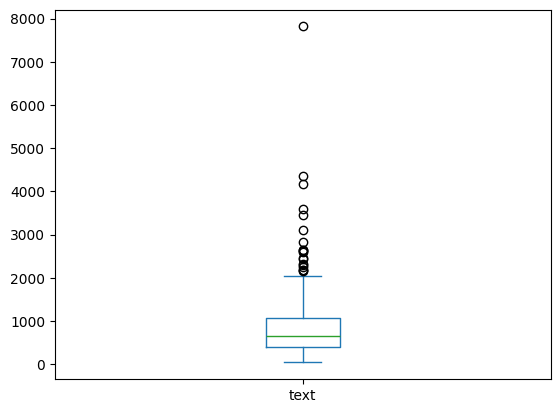

In [ ]:
df.text.apply(len).plot.box()

#### HOLM

In [ ]:
import pandas as pd

holm = pd.read_excel('https://github.com/ipavlopoulos/holm/raw/refs/heads/main/holm_odyssey.xlsx', index_col=0)
holm.sample()

,text,vid,bid,uid,ppl,ivf,ivf_avg,iliad_ppl,odyssey_ppl,cross_score
5614,οὕνεκά μιν κατὰ γῆρας ἔχει χεῖράς τε πόδας τε,497,11,11.497,1333.237153,8.204397,6.137626,1749.673832,677.628675,-1072.045157


In [ ]:
print(holm.columns.values)

['text' 'vid' 'bid' 'uid' 'ppl' 'ivf' 'ivf_avg' 'iliad_ppl' 'odyssey_ppl'
 'cross_score']


In [ ]:
holm.index[:10]

Index([5437, 9431, 5532, 2589, 6210, 5995, 11787, 5418, 8597, 4823], dtype='int64')

In [ ]:
holm["char_length"] = holm["text"].str.len()
holm["word_count"] = holm["text"].str.split().str.len()
holm[["text", "char_length", "word_count"]].head()

,text,char_length,word_count
5437,ἀνθῆσαι πυκάσαι τε γένυς ἐυανθέι λάχνῃ,38,6
9431,δωριέες τε τριχάϊκες δῖοί τε πελασγοί,37,6
5532,ἢ γάμῳ ἢ ἐράνῳ ἢ εἰλαπίνῃ τεθαλυίῃ,34,7
2589,ὡς δ᾽ ἄνεμος ζαὴς ἠΐων θημῶνα τινάξῃ,36,7
6210,αὖτις ἀριζήλως εἰρημένα μυθολογεύειν,36,4


In [ ]:
holm.groupby("bid")["char_length"].mean()

,char_length
bid,
1,42.202703
2,42.511521
3,42.482897
4,42.296340
5,42.300203
6,42.407855
7,42.285303
8,42.349829
9,42.415194


#### PALIT

In [ ]:
import pandas as pd

palit=pd.read_excel("https://raw.githubusercontent.com/ipavlopoulos/palit/refs/heads/main/data/PaLit.xlsx",
                    usecols=["uid", "date", "url", "filename_enc"])
palit.head(1)

,uid,url,date,filename_enc
0,1,http://163.1.169.40/gsdl/collect/POxy/index/as...,-1,1stBC-1stAD_P.Oxy. 2508.jpg


In [ ]:
noise = {18, 64, 66, 86, 98, 135, 140, 156}
palit = palit[~palit.uid.isin(noise)]
palit = palit.drop_duplicates("filename_enc")

In [ ]:
palit.shape

(242, 4)

In [ ]:
palit.to_csv("palit_metadata.csv.gz", index=False, compression="gzip")

In [ ]:
import requests
import os
from tqdm.notebook import tqdm

os.makedirs("palit/data/PLF", exist_ok=True)
for i in tqdm(range(palit.shape[0])):
    try:
        img_data = requests.get(palit.iloc[i].url, timeout=30).content
        with open(f'palit/data/PLF/{palit.iloc[i].filename_enc}', 'wb') as handler:
            handler.write(img_data)
    except:
        print(f'ERROR: {palit.iloc[i].url}')


  0%|          | 0/242 [00:00<?, ?it/s]

ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH7084.dir/POxy.v0030.n2508.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH0195/0e10a8e9.dir/POxy.v0058.n3916.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH7178/d78e9250.dir/POxy.v0053.n3714.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH7178/d78e9250.dir/POxy.v0053.n3714.b.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH01fd/bf4fa778.dir/POxy.v0031.n2555.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH01d6/99088fbc.dir/POxy.v0045.n3264.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH0112/947b3e81.dir/POxy.v0049.n3466.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH016c/51c1c322.dir/POxy.v0042.n3051.a.01.hires.jpg
ERROR: http://163.1.169.40/gsdl/collect/POxy/index/assoc/HASH0198/92913d2d.dir/POxy.v0041.n2957.a.01.hires.jpg
ERROR: htt

In [ ]:
len(os.listdir("palit/data/PLF"))

173

In [ ]:
downloaded_files = os.listdir("palit/data/PLF")
palit = palit[palit["filename_enc"].isin(downloaded_files)]
print(f"Number of entries in palit DataFrame after filtering: {len(palit)}")

Number of entries in palit DataFrame after filtering: 173


In [ ]:
from PIL import Image
import numpy as np

def load_image(path):
    try:
      return np.array(Image.open(path))
    except:
      return None

binary_data = palit["filename_enc"].apply(lambda x: load_image("/content/palit/data/PLF/"+x))

In [ ]:
palit['img_raw'] = binary_data
palit[binary_data.notna()].to_pickle("palit.pkl")

In [ ]:
pd.read_pickle('palit.pkl').sample()

,uid,url,date,filename_enc,img_raw
253,254,http://www.psi-online.it/images/orig/P.%20Laur...,4,5thAD_P.Laur. 141.jpg,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
